# Analysis of 50 IBVS Simulation Log Files

This notebook analyzes:
1. **Terminating poses** - Final poses from each episode
2. **Poses with least error** - Episodes with minimum error_magnitude
3. **Similarity and SSIM** - Distribution and trends of gam_similarity and ssim_score

In [1]:
!pip install seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Load all 50 log files
log_dir = Path("../logs")
log_files = sorted(glob.glob(str(log_dir / "ibvs_sim_*.csv")))

print(f"Found {len(log_files)} log files")
print(f"First file: {log_files[0]}")
print(f"Last file: {log_files[-1]}")

# Load all data
all_data = []
for log_file in log_files:
    df = pd.read_csv(log_file)
    df['episode'] = int(Path(log_file).stem.split('_')[-1])
    all_data.append(df)

# Combine into single dataframe
combined_df = pd.concat(all_data, ignore_index=True)
print(f"\nTotal rows: {len(combined_df)}")
print(f"Columns: {combined_df.columns.tolist()}")
print(f"\nFirst few rows:")
combined_df.head()

Found 50 log files
First file: ../logs/ibvs_sim_001.csv
Last file: ../logs/ibvs_sim_050.csv

Total rows: 4900
Columns: ['iteration', 'error_magnitude', 'distance_to_target', 'oracle_orientation_diff', 'num_matched_keypoints', 'gam_similarity', 'ssim_score', 'robot_pos_x', 'robot_pos_y', 'robot_pos_z', 'robot_orn_x', 'robot_orn_y', 'robot_orn_z', 'target_pos_x', 'target_pos_y', 'target_pos_z', 'image_path', 'episode']

First few rows:


,iteration,error_magnitude,distance_to_target,oracle_orientation_diff,num_matched_keypoints,gam_similarity,ssim_score,robot_pos_x,robot_pos_y,robot_pos_z,robot_orn_x,robot_orn_y,robot_orn_z,target_pos_x,target_pos_y,target_pos_z,image_path,episode
0,0,2747.395752,2.557497,0.132608,42,0.171834,0.653161,0.23226,0.0,1.59921,0.08142,0.04291,-0.09547,0.75,2.5,1.75,/tmp/ibvs_dist_img.png,1
1,1,2872.005127,2.414085,0.116533,51,0.198684,0.681163,0.296222,0.132452,1.621136,0.070737,0.038325,-0.084306,0.75,2.5,1.75,/tmp/ibvs_dist_img.png,1
2,2,2571.875,2.294305,0.110679,64,0.226182,0.688795,0.338557,0.24653,1.621836,0.069353,0.033528,-0.079472,0.75,2.5,1.75,/tmp/ibvs_dist_img.png,1
3,3,2992.382812,2.19642,0.10289,56,0.25368,0.708704,0.37625,0.339125,1.626754,0.065374,0.030124,-0.073519,0.75,2.5,1.75,/tmp/ibvs_dist_img.png,1
4,4,2048.632812,2.113905,0.105591,62,0.280692,0.677815,0.402959,0.419427,1.610799,0.073252,0.02674,-0.071194,0.75,2.5,1.75,/tmp/ibvs_dist_img.png,1


## 1. Terminating Poses Analysis

In [3]:
# Extract terminating poses (last iteration of each episode)
terminating_poses = []
for episode in range(1, 51):
    episode_data = combined_df[combined_df['episode'] == episode]
    if len(episode_data) > 0:
        last_row = episode_data.iloc[-1]
        terminating_poses.append(last_row)

terminating_df = pd.DataFrame(terminating_poses)

print(f"Terminating poses extracted: {len(terminating_df)}")
print(f"\nTerminating poses statistics:")
print(terminating_df[['episode', 'iteration', 'error_magnitude', 'distance_to_target', 
                      'oracle_orientation_diff', 'gam_similarity', 'ssim_score']].describe())

# Position statistics
print(f"\nTerminating position statistics:")
print(terminating_df[['robot_pos_x', 'robot_pos_y', 'robot_pos_z']].describe())

# Orientation statistics
print(f"\nTerminating orientation statistics:")
print(terminating_df[['robot_orn_x', 'robot_orn_y', 'robot_orn_z']].describe())

Terminating poses extracted: 49

Terminating poses statistics:
         episode  iteration  error_magnitude  distance_to_target  \
count  49.000000       49.0        49.000000           49.000000   
mean   25.326531       99.0      1081.724333            1.459363   
std    14.676211        0.0        58.223684            0.000849   
min     1.000000       99.0       970.768250            1.457214   
25%    13.000000       99.0      1034.830688            1.458848   
50%    25.000000       99.0      1076.497437            1.459396   
75%    38.000000       99.0      1118.750000            1.459952   
max    50.000000       99.0      1211.002563            1.461444   

       oracle_orientation_diff  gam_similarity  ssim_score  
count                49.000000       49.000000   49.000000  
mean                  0.008814        0.809248    0.901372  
std                   0.002910        0.002351    0.029570  
min                   0.002830        0.805629    0.818934  
25%                

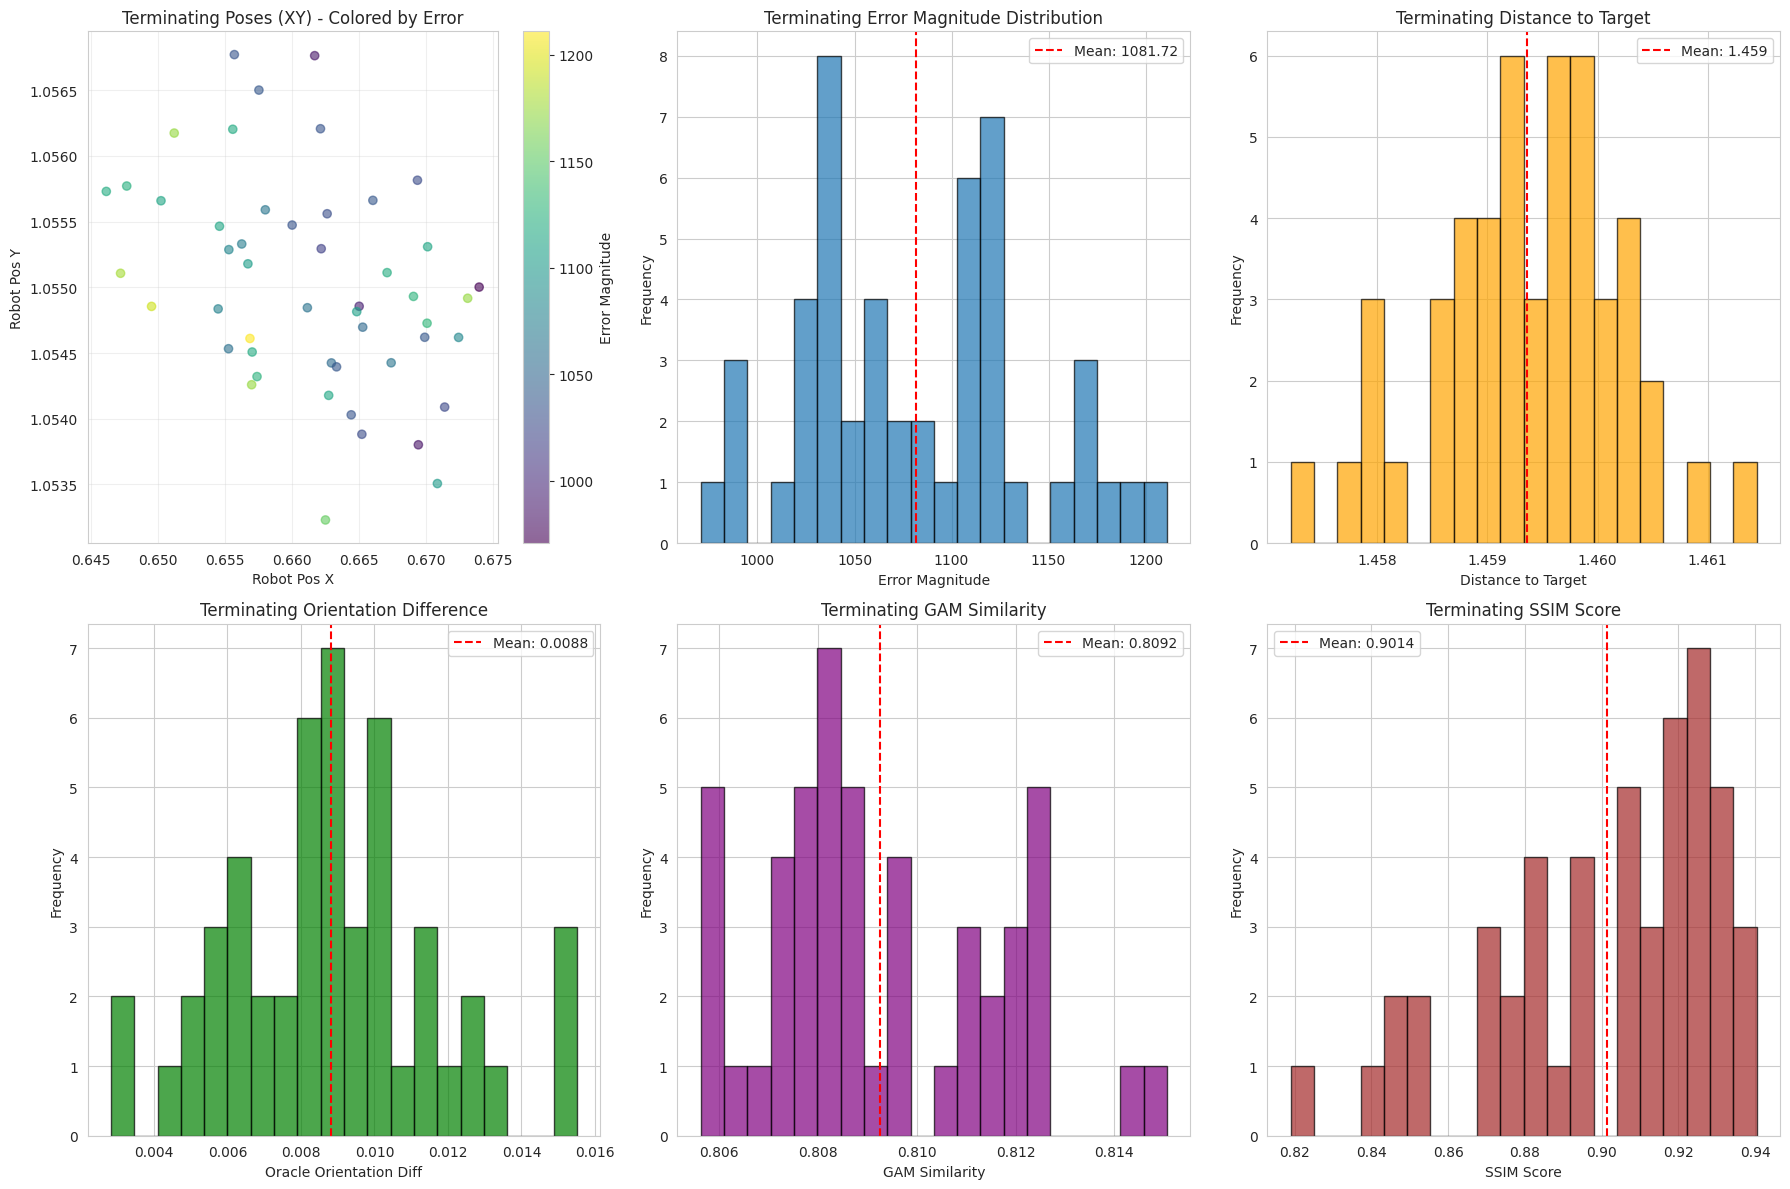


=== TERMINATING POSES SUMMARY ===
Mean Error Magnitude: 1081.72 ± 58.22
Mean Distance to Target: 1.4594 ± 0.0008
Mean Orientation Diff: 0.0088 ± 0.0029
Mean GAM Similarity: 0.8092 ± 0.0024
Mean SSIM Score: 0.9014 ± 0.0296


In [ ]:
# Visualize terminating poses
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Position distribution
axes[0, 0].scatter(terminating_df['robot_pos_x'], terminating_df['robot_pos_y'], 
                   c=terminating_df['error_magnitude'], cmap='viridis', alpha=0.6)
axes[0, 0].set_xlabel('Robot Pos X')
axes[0, 0].set_ylabel('Robot Pos Y')
axes[0, 0].set_title('Terminating Poses (XY) - Colored by Error')
axes[0, 0].grid(True, alpha=0.3)
plt.colorbar(axes[0, 0].collections[0], ax=axes[0, 0], label='Error Magnitude')

# Error magnitude distribution
axes[0, 1].hist(terminating_df['error_magnitude'], bins=20, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Error Magnitude')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Terminating Error Magnitude Distribution')
axes[0, 1].axvline(terminating_df['error_magnitude'].mean(), color='r', 
                   linestyle='--', label=f'Mean: {terminating_df["error_magnitude"].mean():.2f}')
axes[0, 1].legend()

# Distance to target
axes[0, 2].hist(terminating_df['distance_to_target'], bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[0, 2].set_xlabel('Distance to Target')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Terminating Distance to Target')
axes[0, 2].axvline(terminating_df['distance_to_target'].mean(), color='r', 
                   linestyle='--', label=f'Mean: {terminating_df["distance_to_target"].mean():.3f}')
axes[0, 2].legend()

# Orientation difference
axes[1, 0].hist(terminating_df['oracle_orientation_diff'], bins=20, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_xlabel('Oracle Orientation Diff')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Terminating Orientation Difference')
axes[1, 0].axvline(terminating_df['oracle_orientation_diff'].mean(), color='r', 
                   linestyle='--', label=f'Mean: {terminating_df["oracle_orientation_diff"].mean():.4f}')
axes[1, 0].legend()

# GAM Similarity
axes[1, 1].hist(terminating_df['gam_similarity'], bins=20, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_xlabel('GAM Similarity')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Terminating GAM Similarity')
axes[1, 1].axvline(terminating_df['gam_similarity'].mean(), color='r', 
                   linestyle='--', label=f'Mean: {terminating_df["gam_similarity"].mean():.4f}')
axes[1, 1].legend()

# SSIM Score
axes[1, 2].hist(terminating_df['ssim_score'], bins=20, edgecolor='black', alpha=0.7, color='brown')
axes[1, 2].set_xlabel('SSIM Score')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Terminating SSIM Score')
axes[1, 2].axvline(terminating_df['ssim_score'].mean(), color='r', 
                   linestyle='--', label=f'Mean: {terminating_df["ssim_score"].mean():.4f}')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

# Summary statistics
print("\n=== TERMINATING POSES SUMMARY ===")
print(f"Mean Error Magnitude: {terminating_df['error_magnitude'].mean():.2f} ± {terminating_df['error_magnitude'].std():.2f}")
print(f"Mean Distance to Target: {terminating_df['distance_to_target'].mean():.4f} ± {terminating_df['distance_to_target'].std():.4f}")
print(f"Mean Orientation Diff: {terminating_df['oracle_orientation_diff'].mean():.4f} ± {terminating_df['oracle_orientation_diff'].std():.4f}")
print(f"Mean GAM Similarity: {terminating_df['gam_similarity'].mean():.4f} ± {terminating_df['gam_similarity'].std():.4f}")
print(f"Mean SSIM Score: {terminating_df['ssim_score'].mean():.4f} ± {terminating_df['ssim_score'].std():.4f}")

## 2. Poses with Least Error Across Episodes

In [5]:
# Find minimum error for each episode
min_error_poses = []
for episode in range(1, 51):
    episode_data = combined_df[combined_df['episode'] == episode]
    if len(episode_data) > 0:
        min_error_idx = episode_data['error_magnitude'].idxmin()
        min_error_row = episode_data.loc[min_error_idx]
        min_error_poses.append(min_error_row)

min_error_df = pd.DataFrame(min_error_poses)

print(f"Minimum error poses found: {len(min_error_df)}")
print(f"\nMinimum error statistics:")
print(min_error_df[['episode', 'iteration', 'error_magnitude', 'distance_to_target', 
                    'oracle_orientation_diff', 'gam_similarity', 'ssim_score']].describe())

# Compare with terminating poses
print(f"\n=== COMPARISON: Min Error vs Terminating ===")
print(f"Min Error - Mean Error: {min_error_df['error_magnitude'].mean():.2f}")
print(f"Terminating - Mean Error: {terminating_df['error_magnitude'].mean():.2f}")
print(f"Improvement: {terminating_df['error_magnitude'].mean() - min_error_df['error_magnitude'].mean():.2f}")

print(f"\nMin Error - Mean Distance: {min_error_df['distance_to_target'].mean():.4f}")
print(f"Terminating - Mean Distance: {terminating_df['distance_to_target'].mean():.4f}")

print(f"\nMin Error - Mean GAM Similarity: {min_error_df['gam_similarity'].mean():.4f}")
print(f"Terminating - Mean GAM Similarity: {terminating_df['gam_similarity'].mean():.4f}")

print(f"\nMin Error - Mean SSIM: {min_error_df['ssim_score'].mean():.4f}")
print(f"Terminating - Mean SSIM: {terminating_df['ssim_score'].mean():.4f}")

Minimum error poses found: 49

Minimum error statistics:
         episode  iteration  error_magnitude  distance_to_target  \
count  49.000000  49.000000        49.000000           49.000000   
mean   25.326531  69.816327       860.950786            1.567466   
std    14.676211  33.124559       347.916120            0.328434   
min     1.000000   0.000000        48.307293            1.458835   
25%    13.000000  33.000000       734.570312            1.459973   
50%    25.000000  87.000000      1014.518250            1.461030   
75%    38.000000  95.000000      1088.867188            1.509967   
max    50.000000  99.000000      1210.872437            3.243289   

       oracle_orientation_diff  gam_similarity  ssim_score  
count                49.000000       49.000000   49.000000  
mean                  0.044054        0.729275    0.834750  
std                   0.100834        0.178481    0.186171  
min                   0.003383        0.000000    0.000000  
25%                   0.0

/tmp/ipykernel_1373042/2199312052.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([terminating_df['error_magnitude'], min_error_df['error_magnitude']],
/tmp/ipykernel_1373042/2199312052.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 2].boxplot([terminating_df['distance_to_target'], min_error_df['distance_to_target']],
/tmp/ipykernel_1373042/2199312052.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([terminating_df['gam_similarity'], min_error_df['gam_similarity']],
/tmp/ipykernel_1373042/2199312052.py:37: MatplotlibDeprecationWarning: The 'labels' parameter

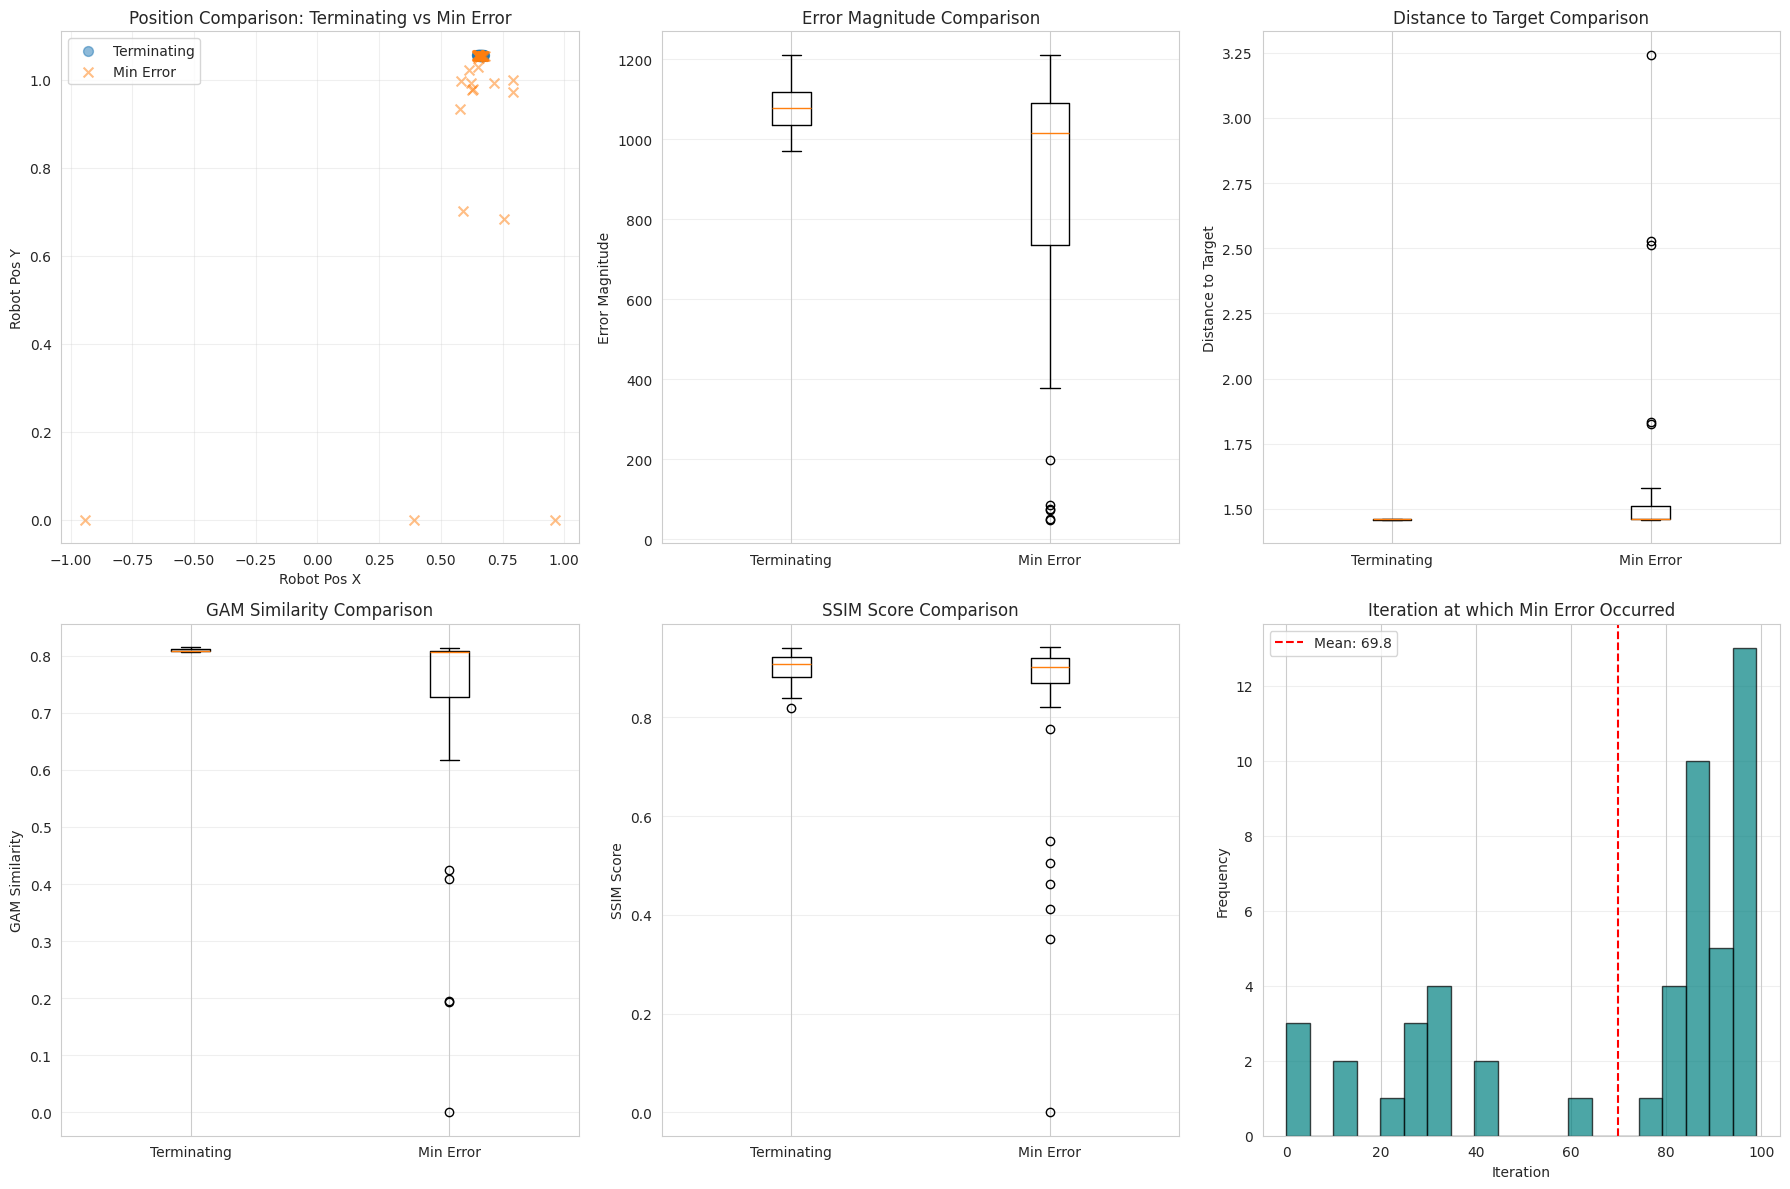


Episodes with significant error improvement (>500): 7
      episode  iteration  error_magnitude
929        10         29        48.307293
1310       14         10        86.067711
1531       16         31        73.111977
3410       36         10       378.580719
3524       37         24        75.195312
3900       41          0        50.976562
4100       43          0       197.591141


In [6]:
# Visualize minimum error poses
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Position comparison
axes[0, 0].scatter(terminating_df['robot_pos_x'], terminating_df['robot_pos_y'], 
                   alpha=0.5, label='Terminating', s=50)
axes[0, 0].scatter(min_error_df['robot_pos_x'], min_error_df['robot_pos_y'], 
                   alpha=0.5, label='Min Error', s=50, marker='x')
axes[0, 0].set_xlabel('Robot Pos X')
axes[0, 0].set_ylabel('Robot Pos Y')
axes[0, 0].set_title('Position Comparison: Terminating vs Min Error')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Error magnitude comparison
axes[0, 1].boxplot([terminating_df['error_magnitude'], min_error_df['error_magnitude']], 
                   labels=['Terminating', 'Min Error'])
axes[0, 1].set_ylabel('Error Magnitude')
axes[0, 1].set_title('Error Magnitude Comparison')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Distance comparison
axes[0, 2].boxplot([terminating_df['distance_to_target'], min_error_df['distance_to_target']], 
                   labels=['Terminating', 'Min Error'])
axes[0, 2].set_ylabel('Distance to Target')
axes[0, 2].set_title('Distance to Target Comparison')
axes[0, 2].grid(True, alpha=0.3, axis='y')

# GAM Similarity comparison
axes[1, 0].boxplot([terminating_df['gam_similarity'], min_error_df['gam_similarity']], 
                   labels=['Terminating', 'Min Error'])
axes[1, 0].set_ylabel('GAM Similarity')
axes[1, 0].set_title('GAM Similarity Comparison')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# SSIM comparison
axes[1, 1].boxplot([terminating_df['ssim_score'], min_error_df['ssim_score']], 
                   labels=['Terminating', 'Min Error'])
axes[1, 1].set_ylabel('SSIM Score')
axes[1, 1].set_title('SSIM Score Comparison')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Iteration at which min error occurred
axes[1, 2].hist(min_error_df['iteration'], bins=20, edgecolor='black', alpha=0.7, color='teal')
axes[1, 2].set_xlabel('Iteration')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Iteration at which Min Error Occurred')
axes[1, 2].axvline(min_error_df['iteration'].mean(), color='r', 
                   linestyle='--', label=f'Mean: {min_error_df["iteration"].mean():.1f}')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Find episodes where min error is significantly better than terminating
error_diff = terminating_df['error_magnitude'].values - min_error_df['error_magnitude'].values
significant_improvements = min_error_df[error_diff > 500]
print(f"\nEpisodes with significant error improvement (>500): {len(significant_improvements)}")
if len(significant_improvements) > 0:
    print(significant_improvements[['episode', 'iteration', 'error_magnitude']].head(10))

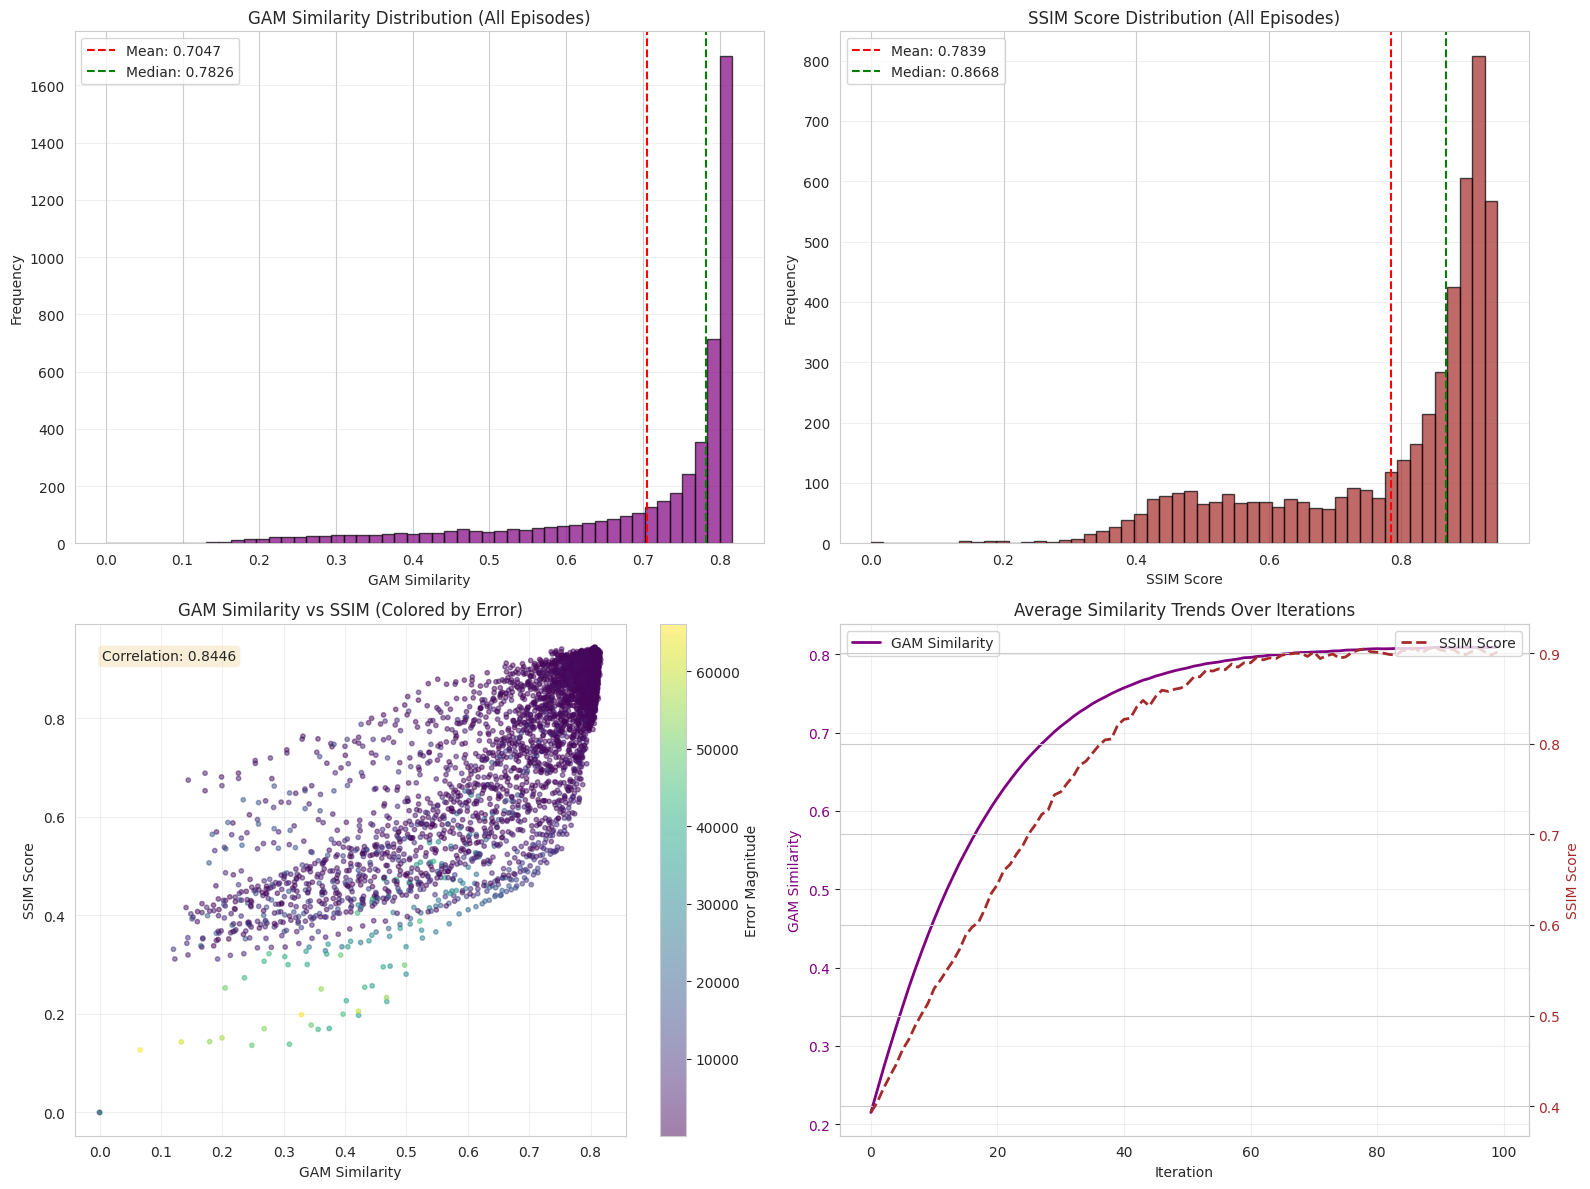


=== SIMILARITY AND SSIM STATISTICS ===
GAM Similarity - Mean: 0.7047, Std: 0.1544
GAM Similarity - Min: 0.0000, Max: 0.8166

SSIM Score - Mean: 0.7839, Std: 0.1710
SSIM Score - Min: 0.0000, Max: 0.9447

Correlation between GAM Similarity and SSIM: 0.8446


In [ ]:
# Analyze similarity and SSIM across all episodes
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# GAM Similarity distribution
axes[0, 0].hist(combined_df['gam_similarity'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[0, 0].set_xlabel('GAM Similarity')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('GAM Similarity Distribution (All Episodes)')
axes[0, 0].axvline(combined_df['gam_similarity'].mean(), color='r', 
                   linestyle='--', label=f'Mean: {combined_df["gam_similarity"].mean():.4f}')
axes[0, 0].axvline(combined_df['gam_similarity'].median(), color='g', 
                   linestyle='--', label=f'Median: {combined_df["gam_similarity"].median():.4f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# SSIM Score distribution
axes[0, 1].hist(combined_df['ssim_score'], bins=50, edgecolor='black', alpha=0.7, color='brown')
axes[0, 1].set_xlabel('SSIM Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('SSIM Score Distribution (All Episodes)')
axes[0, 1].axvline(combined_df['ssim_score'].mean(), color='r', 
                   linestyle='--', label=f'Mean: {combined_df["ssim_score"].mean():.4f}')
axes[0, 1].axvline(combined_df['ssim_score'].median(), color='g', 
                   linestyle='--', label=f'Median: {combined_df["ssim_score"].median():.4f}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# GAM Similarity vs SSIM scatter
scatter = axes[1, 0].scatter(combined_df['gam_similarity'], combined_df['ssim_score'], 
                             c=combined_df['error_magnitude'], cmap='viridis', alpha=0.5, s=10)
axes[1, 0].set_xlabel('GAM Similarity')
axes[1, 0].set_ylabel('SSIM Score')
axes[1, 0].set_title('GAM Similarity vs SSIM (Colored by Error)')
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 0], label='Error Magnitude')

# Correlation analysis
correlation = combined_df['gam_similarity'].corr(combined_df['ssim_score'])
axes[1, 0].text(0.05, 0.95, f'Correlation: {correlation:.4f}', 
                transform=axes[1, 0].transAxes, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                verticalalignment='top')

# Similarity trends over iterations (average across episodes)
avg_by_iteration = combined_df.groupby('iteration')[['gam_similarity', 'ssim_score', 'error_magnitude']].mean()
axes[1, 1].plot(avg_by_iteration.index, avg_by_iteration['gam_similarity'], 
                label='GAM Similarity', linewidth=2, color='purple')
ax2 = axes[1, 1].twinx()
ax2.plot(avg_by_iteration.index, avg_by_iteration['ssim_score'], 
         label='SSIM Score', linewidth=2, color='brown', linestyle='--')
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('GAM Similarity', color='purple')
axes[1, 1].tick_params(axis='y', labelcolor='purple')
ax2.set_ylabel('SSIM Score', color='brown')
ax2.tick_params(axis='y', labelcolor='brown')
axes[1, 1].set_title('Average Similarity Trends Over Iterations')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("\n=== SIMILARITY AND SSIM STATISTICS ===")
print(f"GAM Similarity - Mean: {combined_df['gam_similarity'].mean():.4f}, Std: {combined_df['gam_similarity'].std():.4f}")
print(f"GAM Similarity - Min: {combined_df['gam_similarity'].min():.4f}, Max: {combined_df['gam_similarity'].max():.4f}")
print(f"\nSSIM Score - Mean: {combined_df['ssim_score'].mean():.4f}, Std: {combined_df['ssim_score'].std():.4f}")
print(f"SSIM Score - Min: {combined_df['ssim_score'].min():.4f}, Max: {combined_df['ssim_score'].max():.4f}")
print(f"\nCorrelation between GAM Similarity and SSIM: {correlation:.4f}")

/tmp/ipykernel_1373042/1216916347.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(data_gam, labels=['Terminating', 'Min Error'], patch_artist=True)
/tmp/ipykernel_1373042/1216916347.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(data_ssim, labels=['Terminating', 'Min Error'], patch_artist=True)


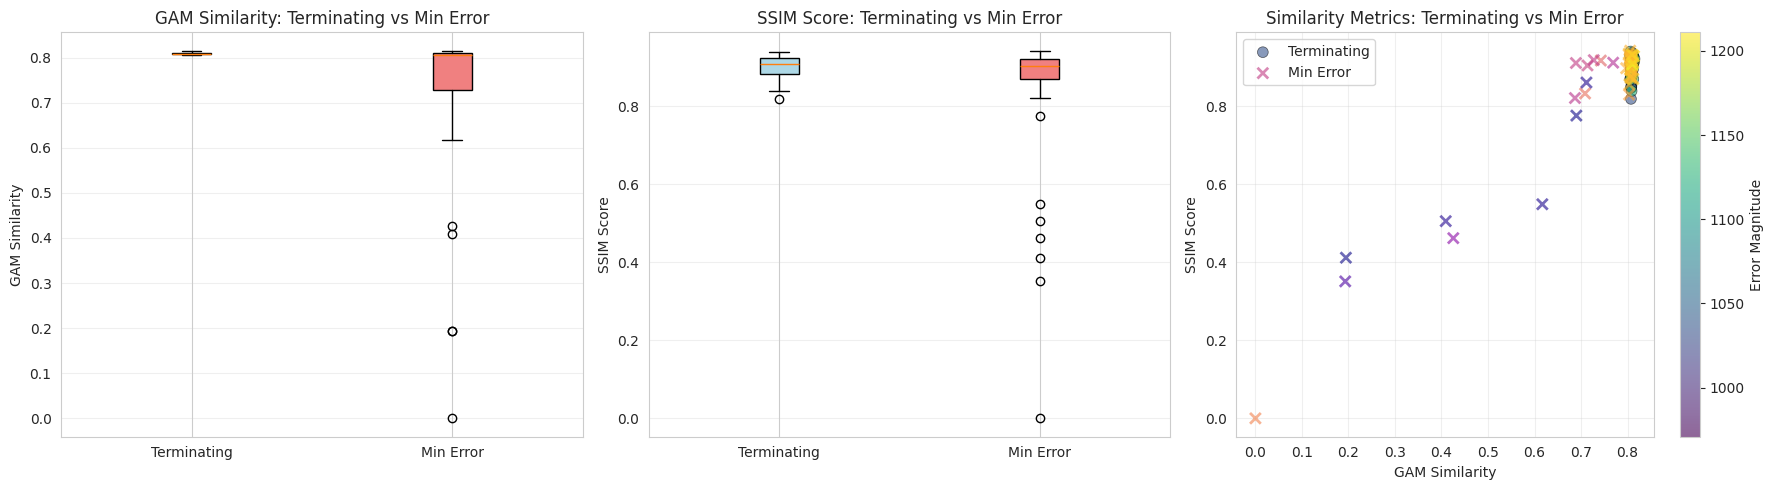


=== CORRELATION ANALYSIS ===
Terminating Poses:
  GAM Similarity vs Error: 0.5579
  SSIM vs Error: 0.1416
  GAM Similarity vs SSIM: 0.2546

Min Error Poses:
  GAM Similarity vs Error: 0.6291
  SSIM vs Error: 0.5601
  GAM Similarity vs SSIM: 0.9622


In [ ]:
# Analyze similarity and SSIM at terminating vs min error poses
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# GAM Similarity comparison
data_gam = [terminating_df['gam_similarity'], min_error_df['gam_similarity']]
bp1 = axes[0].boxplot(data_gam, labels=['Terminating', 'Min Error'], patch_artist=True)
bp1['boxes'][0].set_facecolor('lightblue')
bp1['boxes'][1].set_facecolor('lightcoral')
axes[0].set_ylabel('GAM Similarity')
axes[0].set_title('GAM Similarity: Terminating vs Min Error')
axes[0].grid(True, alpha=0.3, axis='y')

# SSIM comparison
data_ssim = [terminating_df['ssim_score'], min_error_df['ssim_score']]
bp2 = axes[1].boxplot(data_ssim, labels=['Terminating', 'Min Error'], patch_artist=True)
bp2['boxes'][0].set_facecolor('lightblue')
bp2['boxes'][1].set_facecolor('lightcoral')
axes[1].set_ylabel('SSIM Score')
axes[1].set_title('SSIM Score: Terminating vs Min Error')
axes[1].grid(True, alpha=0.3, axis='y')

# Scatter: Error vs Similarity metrics
scatter1 = axes[2].scatter(terminating_df['gam_similarity'], terminating_df['ssim_score'], 
                          c=terminating_df['error_magnitude'], cmap='viridis', 
                          alpha=0.6, s=60, label='Terminating', edgecolors='black', linewidth=0.5)
scatter2 = axes[2].scatter(min_error_df['gam_similarity'], min_error_df['ssim_score'], 
                          c=min_error_df['error_magnitude'], cmap='plasma', 
                          alpha=0.6, s=60, label='Min Error', marker='x', linewidth=2)
axes[2].set_xlabel('GAM Similarity')
axes[2].set_ylabel('SSIM Score')
axes[2].set_title('Similarity Metrics: Terminating vs Min Error')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[2], label='Error Magnitude')

plt.tight_layout()
plt.show()

# Correlation analysis for terminating and min error
print("\n=== CORRELATION ANALYSIS ===")
print("Terminating Poses:")
print(f"  GAM Similarity vs Error: {terminating_df['gam_similarity'].corr(terminating_df['error_magnitude']):.4f}")
print(f"  SSIM vs Error: {terminating_df['ssim_score'].corr(terminating_df['error_magnitude']):.4f}")
print(f"  GAM Similarity vs SSIM: {terminating_df['gam_similarity'].corr(terminating_df['ssim_score']):.4f}")

print("\nMin Error Poses:")
print(f"  GAM Similarity vs Error: {min_error_df['gam_similarity'].corr(min_error_df['error_magnitude']):.4f}")
print(f"  SSIM vs Error: {min_error_df['ssim_score'].corr(min_error_df['error_magnitude']):.4f}")
print(f"  GAM Similarity vs SSIM: {min_error_df['gam_similarity'].corr(min_error_df['ssim_score']):.4f}")

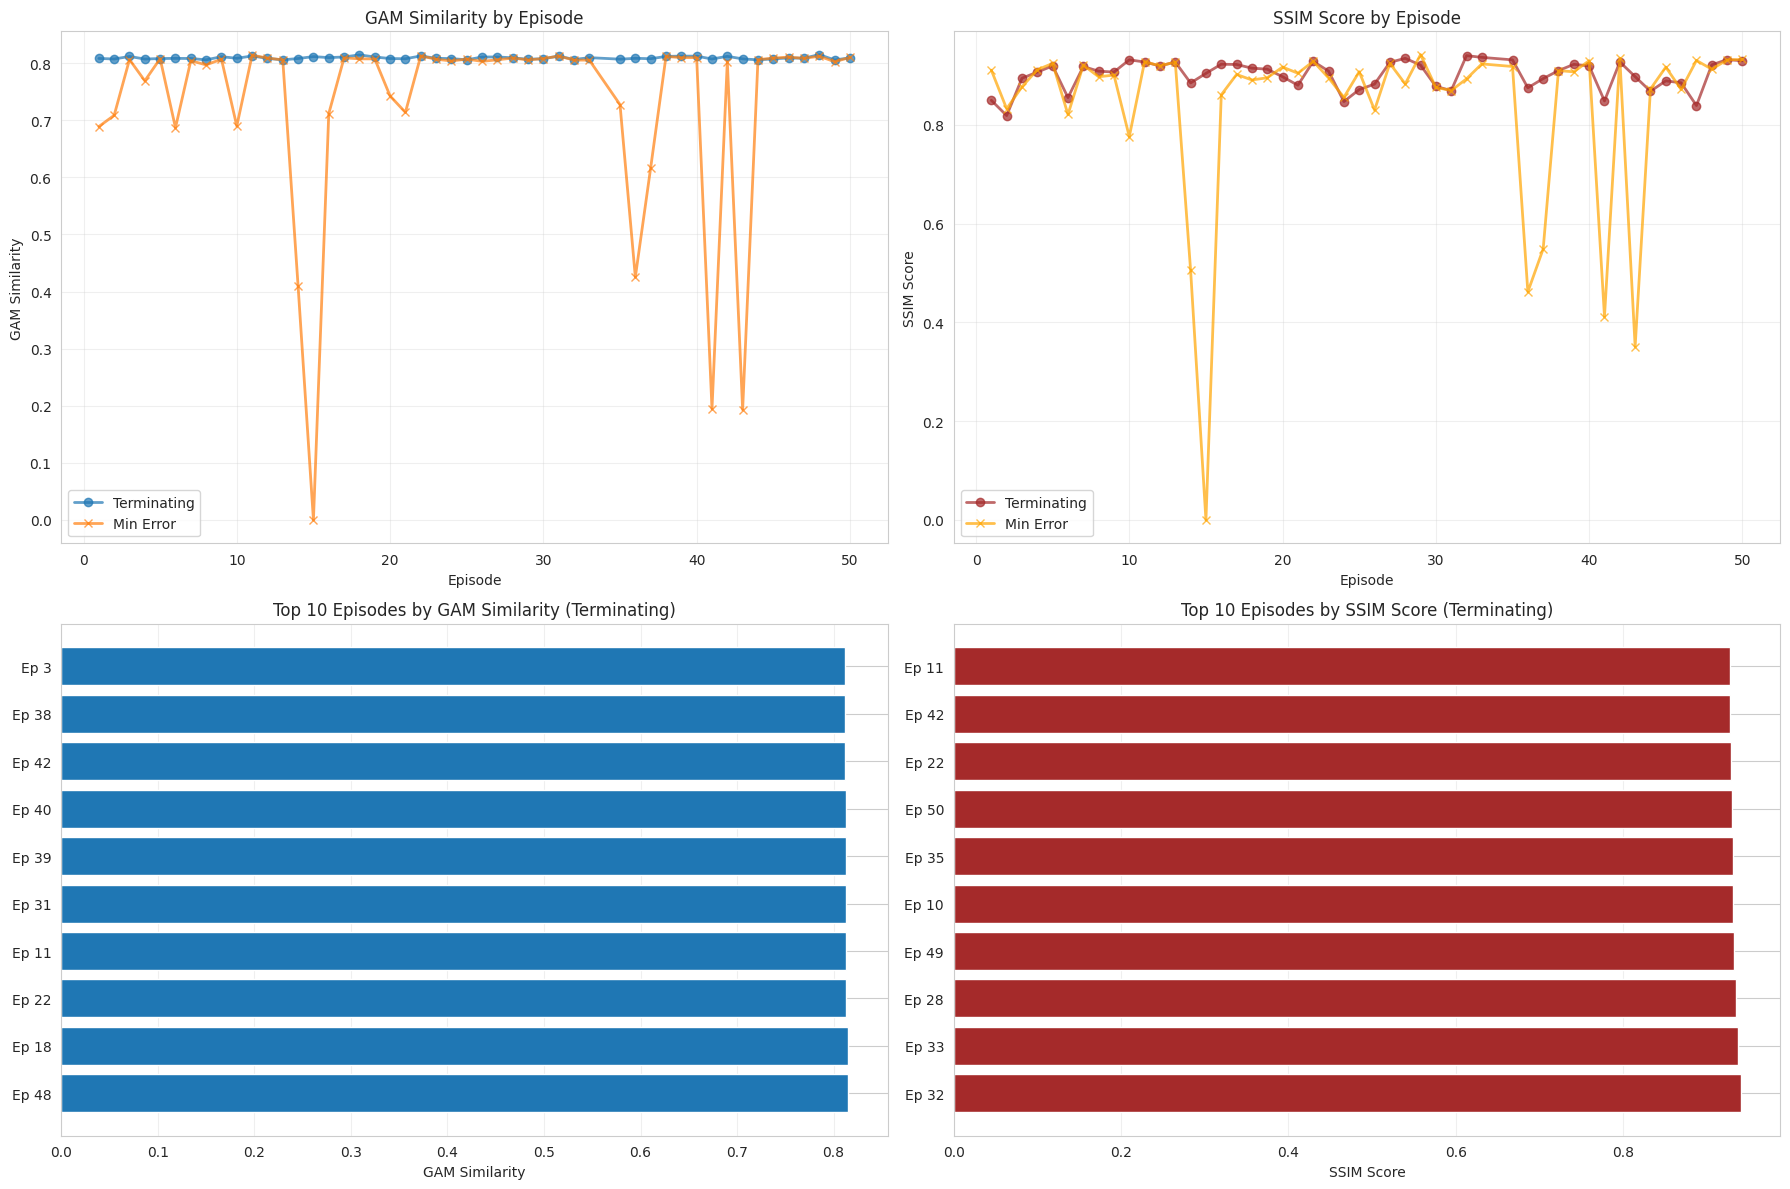


=== TOP PERFORMING EPISODES ===

Top 5 by GAM Similarity (Terminating):
      episode  gam_similarity  ssim_score  error_magnitude
4699       48        0.815064    0.921759      1106.380249
1799       18        0.814579    0.914979      1192.968750
2199       22        0.812692    0.928803      1153.255249
1099       11        0.812638    0.927503      1111.718750
3099       31        0.812476    0.869659      1128.710938

Top 5 by SSIM Score (Terminating):
      episode  gam_similarity  ssim_score  error_magnitude
3199       32        0.806438    0.940436      1103.776001
3299       33        0.809727    0.936831      1036.848999
2799       28        0.809403    0.934972      1120.572876
4799       49        0.805629    0.932227      1059.635376
999        10        0.808648    0.931858       985.286438


In [ ]:
# Episode-by-episode analysis of similarity metrics
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# GAM Similarity by episode (terminating)
episode_gam_term = terminating_df.groupby('episode')['gam_similarity'].mean()
episode_gam_min = min_error_df.groupby('episode')['gam_similarity'].mean()

axes[0, 0].plot(episode_gam_term.index, episode_gam_term.values, 
                'o-', label='Terminating', alpha=0.7, linewidth=2)
axes[0, 0].plot(episode_gam_min.index, episode_gam_min.values, 
                'x-', label='Min Error', alpha=0.7, linewidth=2)
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('GAM Similarity')
axes[0, 0].set_title('GAM Similarity by Episode')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# SSIM by episode (terminating)
episode_ssim_term = terminating_df.groupby('episode')['ssim_score'].mean()
episode_ssim_min = min_error_df.groupby('episode')['ssim_score'].mean()

axes[0, 1].plot(episode_ssim_term.index, episode_ssim_term.values, 
                'o-', label='Terminating', alpha=0.7, linewidth=2, color='brown')
axes[0, 1].plot(episode_ssim_min.index, episode_ssim_min.values, 
                'x-', label='Min Error', alpha=0.7, linewidth=2, color='orange')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('SSIM Score')
axes[0, 1].set_title('SSIM Score by Episode')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Best episodes by GAM Similarity
top_gam = terminating_df.nlargest(10, 'gam_similarity')
axes[1, 0].barh(range(len(top_gam)), top_gam['gam_similarity'].values)
axes[1, 0].set_yticks(range(len(top_gam)))
axes[1, 0].set_yticklabels([f"Ep {int(e)}" for e in top_gam['episode'].values])
axes[1, 0].set_xlabel('GAM Similarity')
axes[1, 0].set_title('Top 10 Episodes by GAM Similarity (Terminating)')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Best episodes by SSIM
top_ssim = terminating_df.nlargest(10, 'ssim_score')
axes[1, 1].barh(range(len(top_ssim)), top_ssim['ssim_score'].values, color='brown')
axes[1, 1].set_yticks(range(len(top_ssim)))
axes[1, 1].set_yticklabels([f"Ep {int(e)}" for e in top_ssim['episode'].values])
axes[1, 1].set_xlabel('SSIM Score')
axes[1, 1].set_title('Top 10 Episodes by SSIM Score (Terminating)')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n=== TOP PERFORMING EPISODES ===")
print("\nTop 5 by GAM Similarity (Terminating):")
print(top_gam[['episode', 'gam_similarity', 'ssim_score', 'error_magnitude']].head(5))

print("\nTop 5 by SSIM Score (Terminating):")
print(top_ssim[['episode', 'gam_similarity', 'ssim_score', 'error_magnitude']].head(5))

## Summary Statistics

In [10]:
# Create comprehensive summary
summary_stats = {
    'Metric': [
        'Terminating - Mean Error',
        'Terminating - Mean Distance',
        'Terminating - Mean Orientation Diff',
        'Terminating - Mean GAM Similarity',
        'Terminating - Mean SSIM',
        'Min Error - Mean Error',
        'Min Error - Mean Distance',
        'Min Error - Mean Orientation Diff',
        'Min Error - Mean GAM Similarity',
        'Min Error - Mean SSIM',
        'All Data - Mean GAM Similarity',
        'All Data - Mean SSIM',
        'GAM-SSIM Correlation (All)',
        'GAM-SSIM Correlation (Terminating)',
        'GAM-SSIM Correlation (Min Error)'
    ],
    'Value': [
        f"{terminating_df['error_magnitude'].mean():.2f} ± {terminating_df['error_magnitude'].std():.2f}",
        f"{terminating_df['distance_to_target'].mean():.4f} ± {terminating_df['distance_to_target'].std():.4f}",
        f"{terminating_df['oracle_orientation_diff'].mean():.4f} ± {terminating_df['oracle_orientation_diff'].std():.4f}",
        f"{terminating_df['gam_similarity'].mean():.4f} ± {terminating_df['gam_similarity'].std():.4f}",
        f"{terminating_df['ssim_score'].mean():.4f} ± {terminating_df['ssim_score'].std():.4f}",
        f"{min_error_df['error_magnitude'].mean():.2f} ± {min_error_df['error_magnitude'].std():.2f}",
        f"{min_error_df['distance_to_target'].mean():.4f} ± {min_error_df['distance_to_target'].std():.4f}",
        f"{min_error_df['oracle_orientation_diff'].mean():.4f} ± {min_error_df['oracle_orientation_diff'].std():.4f}",
        f"{min_error_df['gam_similarity'].mean():.4f} ± {min_error_df['gam_similarity'].std():.4f}",
        f"{min_error_df['ssim_score'].mean():.4f} ± {min_error_df['ssim_score'].std():.4f}",
        f"{combined_df['gam_similarity'].mean():.4f} ± {combined_df['gam_similarity'].std():.4f}",
        f"{combined_df['ssim_score'].mean():.4f} ± {combined_df['ssim_score'].std():.4f}",
        f"{combined_df['gam_similarity'].corr(combined_df['ssim_score']):.4f}",
        f"{terminating_df['gam_similarity'].corr(terminating_df['ssim_score']):.4f}",
        f"{min_error_df['gam_similarity'].corr(min_error_df['ssim_score']):.4f}"
    ]
}

summary_df = pd.DataFrame(summary_stats)
print("\n" + "="*60)
print("COMPREHENSIVE SUMMARY STATISTICS")
print("="*60)
print(summary_df.to_string(index=False))
print("="*60)


COMPREHENSIVE SUMMARY STATISTICS
                             Metric           Value
           Terminating - Mean Error 1081.72 ± 58.22
        Terminating - Mean Distance 1.4594 ± 0.0008
Terminating - Mean Orientation Diff 0.0088 ± 0.0029
  Terminating - Mean GAM Similarity 0.8092 ± 0.0024
            Terminating - Mean SSIM 0.9014 ± 0.0296
             Min Error - Mean Error 860.95 ± 347.92
          Min Error - Mean Distance 1.5675 ± 0.3284
  Min Error - Mean Orientation Diff 0.0441 ± 0.1008
    Min Error - Mean GAM Similarity 0.7293 ± 0.1785
              Min Error - Mean SSIM 0.8347 ± 0.1862
     All Data - Mean GAM Similarity 0.7047 ± 0.1544
               All Data - Mean SSIM 0.7839 ± 0.1710
         GAM-SSIM Correlation (All)          0.8446
 GAM-SSIM Correlation (Terminating)          0.2546
   GAM-SSIM Correlation (Min Error)          0.9622


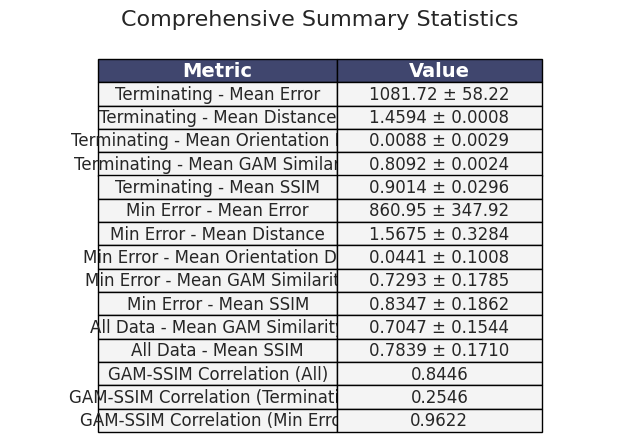

In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))

# Hide axes
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.axis('off')

# Make a table from the DataFrame
table = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    loc='center',
    cellLoc='center',
    colColours=['#40466e', '#40466e'],
    colWidths=[0.35, 0.3]
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.1, 1.4)

# Highlight the header row
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_fontsize(14)
        cell.set_text_props(weight='bold', color='w')
        cell.set_facecolor("#40466e")
    else:
        cell.set_facecolor("#f4f4f4")

plt.title("Comprehensive Summary Statistics", fontsize=16, pad=20)
plt.show()